# Day 1 – Unsupervised Learning and K-Means Clustering
## Learning Objectives
By the time you complete this notebook, you will be able to:
- Distinguish between supervised and unsupervised learning.
- Define clustering.
- Understand the process of K-means clustering.
- Scale numeric features for clustering.
- Apply the elbow method to determine the optimal number of Ks.
- Apply silhouette score to evaluate the candidates of K values.
- Train a K-means model using the final K value.
- Visualize the clusters and analyze their characteristics.

## what is the difference between Supervised vs Unsupervised Learning?
In supervised learning:
- X --> input variables
- y --> target
The model learns the connection between X and y to predict results.
Types:
- Regression
- Classification
In unsupervised learning, there is no target variable.
The algorithm gets X only and attempts to uncover any patterns or groups inside the data.
Types:
- Clustering
- Dimensionality reduction
- Anomaly detection
### Main difference
| Supervised Learning | Unsupervised Learning |
|---------------------|----------------------|
| Uses X and y       | Uses X only          |
| Known target        | No target            |
| Predict target      | Discover structure   |

## Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

## Load the Dataset
We use the Credit Card Fraud Detection dataset from Kaggle and load it using pandas library.
It consists of credit card transactions with numeric features and the Class,column that defines whether the transaction is fraudulent.
For this unsupervised learning task, Class will not be considered as an input feature.

In [22]:
df=pd.read_csv("creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [24]:
df.shape

(284807, 31)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

##  Analysis of the Data Set
This data set includes:
- Time: time since the first transaction.
- V1 to V28: anonymized numeric attributes.
- Amount: amount of the transaction.
- Class: class of fraud.
The Class attribute has the following values of fraud:
- 0 --> legitimate transaction
- 1 --> fraud transaction

## Scale the Dataset
First, we separate the target column Class from the input features.
The target is kept separately because we do not want K-Means to use
the known fraud labels.

In [29]:
x=df.drop("Class",axis=1)
print("x shape is:",x.shape)

x shape is: (284807, 30)


### Why Do We Not Use Class?
The class feature helps us know if the transaction is fraud or not.
Using this feature with K-Means will mean giving the algorithm the answer to the problem we are trying to find.
Thus:
- X --> Clustering
- Class --> Not used by K-Means

In [30]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled.shape

(284807, 30)

### Why do we use StandardScaler?
K-Means is a distance-based model.
**When one variable is much higher in value than another variable, it could dominate the distances that are computed**
StandardScaler makes all the features comparable to each other,this allows K-Means to compute the distances in a more balanced way.

## Create a sample for faster clustering Evaluation.
To make the Elbow Method and Silhouette Score calculations more efficient, we use `train_test_split` to select a reproducible sample of 10,000 observations.
The train_size=10000 parameter keeps 10,000 observations in x_sample, while _ stores the remaining observations that are not needed for this step.
The random_state=42 ensures that the same sample is selected every time the notebook is executed.

In [34]:
x_sample, _ = train_test_split(x_scaled, train_size=10000, random_state=42)
print(x_sample.shape)

(10000, 30)


train_test_split will return a list since it divides the dataset into several subsets, and assigning it to one variable will return a list in Python rather than an array or DataFrame (the cause of .shape error).
Use of x_sample, _ : We unpack the list into two separate variables. One of the variables, namely x_sample, stores our 10,000-sample, while the other variable, _, stores the rest of the data that is unnecessary for us.

## What is Clustering?
Clustering is an unsupervised learning technique that groups similar data points together based on their features.
The algorithm does not use predefined labels. Instead, it tries to discover natural groups within the data.
In this dataset, clustering can help identify groups of transactions that have similar numerical patterns.
The goal is to make:
- Data points within the same cluster as similar as possible.
- Data points in different clusters as different as possible.

## Understanding the Process of K-Means
K-Means segregates observations into clusters based on a certain number of K,it basically does the following steps iteratively:
- Allocate observations to the closest centroid.
- Shift each centroid to the mean location of the allocated observations.
It continues doing this process till centroids stabilize.
Centroid can be considered as the center of a cluster.

In [36]:
km=KMeans(n_clusters=3,random_state=42,n_init=10)
labels=km.fit_predict(x_sample)
print("cluster label is:",labels[:10])
print("centroid shape is:",km.cluster_centers_.shape)

cluster label is: [2 2 1 2 2 2 2 1 1 2]
centroid shape is: (3, 30)


### Understanding of K-means Centroid Shape
3: Refers to the number of clusters (n_clusters=3) defined.It implies that there were 3 centers formed in the clustering algorithm.
30: Refers to the number of columns/features in the scaled data set (x_sample).

## Determining K - Elbow Method
The choice of number of clusters K is necessary in K-Means.we will run the algorithm for K = 1 to 10.
For each K value we compute the value of inertia.
### Inertia
Inertia is the sum of within-cluster distances between observations and cluster centers,Inertia gets lower as K gets higher.
We need to find the "elbow point" where the increase of K doesn't improve results significantly.

## Example: Running K-Means
Before determining the optimal number of clusters, we use K=3 as a simple example to demonstrate how K-Means assigns observations to clusters and calculates centroids.
This is only an educational example. The final value of K will be selected later using the Elbow Method and Silhouette Score.

In [37]:
inertias=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(x_sample)
    inertias.append(km.inertia_)

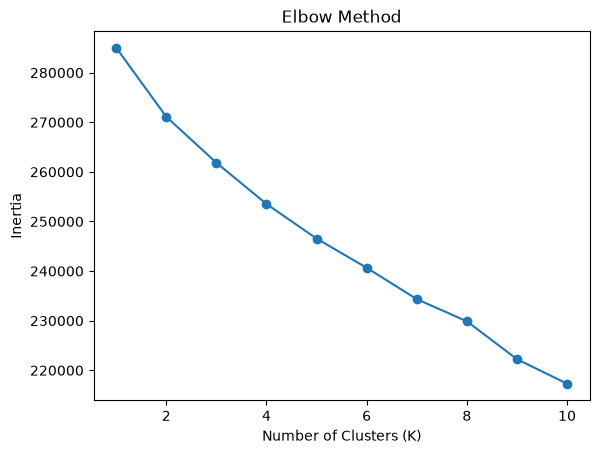

In [55]:
plt.plot(range(1,11),inertias,marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Elbow Explanation
As K increases, the inertia reduces.,we search for the place that marks where the graph begins to become flat.
That point is referred to as the elbow,the elbow serves as the candidate for the number of clusters.
From the Plot, we shall choose the two most plausible K candidates and compare them using the Silhouette Score.

## Silhouette Score
### Determining K – Silhouette Score
The Silhouette Score is an indicator of clustering performance that is quantitative in nature.
**It can be anywhere between -1 and +1.**
- High scores indicate good separation and definition of clusters.
- Scores near 0 suggest overlapping clusters.
- Negative scores could mean bad clustering.
The Silhouette Score will be calculated for the two K values,determined by the Elbow Method.

### Candidate K Values
Based on the Elbow Method plot, the decrease in inertia becomes more gradual around K=3 and K=4,therefore, K=3 and K=4 are selected as candidate values for further evaluation.
Since the Elbow Method provides a visual indication rather than a definitive answer, we use the Silhouette Score to quantitatively compare these two candidate values.

In [41]:
candidate_k=[3,4]

In [43]:
silhouette_scores = {}
for k in candidate_k:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    sample_labels = km.fit_predict(x_sample)
    score = silhouette_score(x_sample,sample_labels)
    silhouette_scores[k] = score
silhouette_scores

{3: 0.0740928516937891, 4: 0.07352696632050314}

In [44]:
for k, score in silhouette_scores.items():
    print(f"K = {k}: Silhouette Score = {score}")

K = 3: Silhouette Score = 0.0740928516937891
K = 4: Silhouette Score = 0.07352696632050314


In [45]:
best_k = max(silhouette_scores,key=silhouette_scores.get)
print("Best K:", best_k)
print("Best Silhouette Score:",round(silhouette_scores[best_k], 4))

Best K: 3
Best Silhouette Score: 0.0741


### Determination of the Final K
We make a comparison of the Silhouette scores for our two choices,the choice of K that has a greater Silhouette score indicates more defined clusters.
The selected value is used as the final K for the K-Means model.

## Final K-Means
### Final K-Means Model
After selecting the optimal value for K, we proceed with training the final K-Means model.
Different from the Elbow method and the Silhouette score calculation, the final model
will make use of the full data set,this ensures that the final model has access to all available data points.

In [46]:
final_kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=10)
labels=final_kmeans.fit_predict(x_scaled)
labels[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

### Understanding Cluster Labels Output
* Array (labels[:20]): Represents the clusters labels of the first 20 rows of your complete dataset (x_scaled).
* Clusters ID (0): Suggests that the first 20 rows of transactions have been labeled as belonging to cluster 0 based on the K-Means final model.
* Type (dtype=int32): Reveals the type of data in labels, which is 32-bit integer numbers.

In [48]:
df["Cluster"]=labels
df["Cluster"].value_counts().sort_index()

Cluster
0    151888
1    128217
2      4702
Name: count, dtype: int64

### Cluster Labels
The Cluster field shows the cluster that the particular transaction belongs to.
Example:
- Cluster 0 --> transactions in the first cluster
- Cluster 1 --> transactions in the second cluster
- Cluster 2 --> transactions in the third cluster
These labels themselves don’t carry any significance.
Cluster 0 is not superior or inferior compared to Cluster 1.
The significance of each cluster should be derived by analyzing the
nature of observations within it.

## Cluster Centroid

In [49]:
final_kmeans.cluster_centers_

array([[-7.74118948e-01, -1.53138439e-01,  6.52981610e-02,
         4.96517230e-01,  8.52485907e-02, -1.44903201e-01,
         6.75089714e-02, -1.24576895e-01,  6.40102613e-02,
        -8.42246540e-02, -1.81541147e-02,  1.84262796e-01,
        -1.12082984e-02, -2.34628112e-03,  3.96624486e-02,
         2.41033091e-01, -2.37015571e-02,  4.46783165e-02,
        -7.99827198e-02,  2.18096831e-02,  2.01865584e-02,
        -6.91344675e-02, -1.59171329e-01, -6.42674712e-02,
         9.15546695e-03,  3.17981396e-01,  4.82259068e-02,
        -2.00822679e-03,  3.44757619e-03, -8.06027385e-02],
       [ 9.17820957e-01,  2.32862771e-01,  3.12208698e-02,
        -5.39500479e-01, -1.23983476e-01,  2.41883387e-01,
        -1.17619669e-01,  6.70160634e-02, -5.55102975e-02,
         1.08706092e-01,  4.21224434e-02, -2.18848776e-01,
         1.45532950e-02,  1.77911214e-03, -5.74920115e-02,
        -2.84650526e-01,  2.45131173e-02, -5.64457544e-02,
         9.19354644e-02, -1.48563741e-02, -1.04605401e-

### Cluster Centroids
The centroid is the central point of the cluster,since the model was developed on standardized features, the values of
the centroid are also standardized.
**If the value is positive, it means that the corresponding featurevalue is relatively high, while negative values imply relatively lowfeature values.**
The centroids give insights into the nature of the cluster members.

### Visualization of Clusters
Since our dataset contains 30 features, it is not possible to visualize
the clusters in all dimensions,to perform 2D visualization, we will plot two features after standardization.

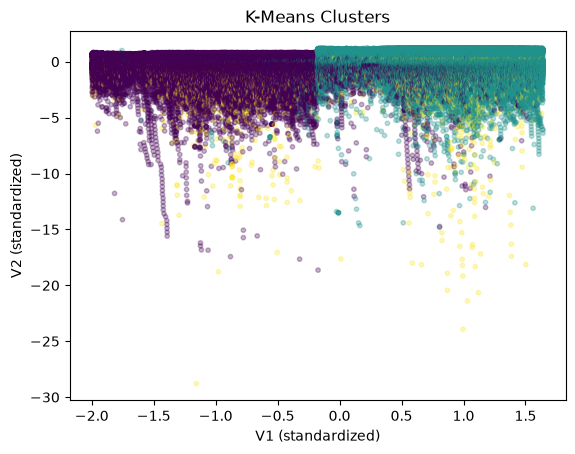

In [51]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=labels,alpha=0.3,s=10)
plt.xlabel("V1 (standardized)")
plt.ylabel("V2 (standardized)")
plt.title("K-Means Clusters")
plt.show()

### Plot Analysis
* Scatter Plot (plt.scatter): It uses the standardized features in columns `V1` and `V2` on the x and y axes, respectively, to plot the data and visualize how the K-means algorithm has partitioned the data.
* **Cluster Colors (c=labels): It assigns color to each data point depending on its assigned cluster label to distinguish various clusters visually.
* Transparency and Size (alpha=0.3, s=10): Transparency and size are adjusted to make it easier to see the density and overlaps in the plot.

In [ ]:
cluster_means=df.groupby("Cluster")[x.columns].mean()
cluster_means


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Cluster,,,,,,,,,,,,,,,,,,,,,
0,58054.386680,-0.299969,0.107867,0.752861,0.120662,-0.199965,0.089964,-0.154118,0.076464,-0.092553,...,0.015539,-0.050786,-0.115505,-0.040129,0.005540,0.165764,0.023247,-0.000812,0.001133,68.179706
1,138399.027828,0.456155,0.051556,-0.818059,-0.175519,0.333877,-0.156760,0.082883,-0.066316,0.119453,...,-0.080640,0.042545,0.150906,0.064758,-0.007791,-0.190619,-0.028010,0.001097,-0.003009,62.266816
2,93742.677371,-2.748857,-4.890286,-2.012245,0.888452,-2.644920,1.368532,2.718343,-0.661656,-0.267604,...,1.697005,0.480375,-0.383841,-0.469558,0.033496,-0.156735,0.012855,-0.003709,0.045456,1451.137074


In [56]:
cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_percentages = (df["Cluster"].value_counts(normalize=True).sort_index().mul(100).round(2))
cluster_summary = pd.DataFrame({"Count": cluster_counts,"Percentage": cluster_percentages})
cluster_summary

,Count,Percentage
Cluster,,
0,151888,53.33
1,128217,45.02
2,4702,1.65


### Cluster Distribution
The cluster distribution shows how many transactions were assigned to each cluster and what percentage of the dataset each cluster represents.
This helps us understand whether the discovered clusters are relatively balanced or whether one cluster contains most of the transactions.

### Clusters Interpretation
Clusters stand for groups of transactions which have similarities in their
numeric transaction features.
Variables V1-V28 are anonymized PCA components, hence, the individual business
meaning is unknown.
So, we should not make up any specific interpretations like "V1 means age of
customers".
We may interpret our clusters in terms of differences between the values of
the features.
For instance:
- A cluster with higher standardized Amount consists of transactions with
relatively larger amounts.
- A cluster with lower standardized Amount consists of transactions with
relatively smaller amounts.
- V1-V28 differences mean the differences in the underlying transaction
patterns described by anonymized components.
Thus, each cluster is a set of transactions with similar patterns based on
their features.

# Hands-On-Lab -All Tasks Completed
## Step 1: Load and scale a provided dataset (numeric features only) with StandardScaler.
We did this by:
- Loading the Credit Card Fraud Detection dataset.
- Separating the Class column from the input features.
- Using only the transaction features as X.
- Applying StandardScaler to scale all numerical features.
This prepares the data for K-Means, which depends on distance calculations.
## Step 2: Run K-Means for k from 1 to 10 and plot inertia to find the elbow.
We did this by:
- Creating a 10,000-row sample to make the calculations faster.
- Running K-Means for K values from 1 to 10.
- Calculating the inertia for each K.
- Plotting the inertia values using the Elbow Method.
- Using the elbow in the plot to identify two reasonable candidate values of K.
This helped us narrow down the possible number of clusters
## Step 3: Compute the silhouette score for the top two candidate k values and pick the best.
We did this by:
- Taking the two candidate K values identified from the Elbow Method.
- Running K-Means for each candidate K.
- Calculating the Silhouette Score using the 10,000-row sample.
- Comparing the scores.
- Selecting the optimal K based on the Silhouette Score comparison.
This provided a quantitative check for the choice suggested by the
Elbow Method.
## Step 4: Fit final K-Means with the chosen k, and visualize the clusters on a 2D scatter plot.
We did this by:
- The optimum K obtained through Silhouette Score.
- Fitting our final K-Means algorithm.
- Training our model on the entire scaled data set.
- Assigning each transaction to one of the discovered clusters.
- Analyzing the centroids of the clusters.
- Visualization of the obtained clusters using a scatter plot.
Hence, our final model has used all the transactions available.
## Step 5: Interpret what each cluster represents in a Markdown cell.
We did this by:
- Computing the mean value of the features for each cluster.
- Studying the properties of the discovered clusters.
- Analyzing the centroid values of the clusters.
- Using the values of the features to explain differences between the clusters.
Since V1 to V28 are the PCA features with anonymized labels, we
interpret them as relative numerical patterns and not assign them any real
life meaning,this means that the clusters are groups of transactions with similar
numerical patterns.